# Introduction

An online resource was consulted for the purposes of rendering gymnasium environments in jupyter notebooks. This resource can be found at the following link and is referenced multiple times throughout this assignment:

- Source A: https://community.latenode.com/t/how-to-render-gymnasium-environment-inside-jupyter-without-external-window/30582/4


## Setup


In [29]:
# =============================== Taken from Source A ===================
import sys
from pathlib import Path

for _p in (Path.cwd(), *Path.cwd().parents):
    if (_p / "src" / "rl_suite").is_dir():
        sys.path.insert(0, str(_p / "src"))
        break

from IPython import display
import matplotlib.pyplot as plt
%matplotlib inline
# =======================================================================
from abc import ABC, abstractmethod
import gymnasium as gym
import numpy as np
import pprint  # useful for printing nested items

from rl_suite import run_frozen_lake_episode, get_spaces_from_env

In [30]:
ENV_ID = "FrozenLake-v1"
GOAL_REWARD, HOLE_REWARD, OTHER_REWARD = 1000, -5, 0
IS_SLIPPERY = False
SEED = 10

env = gym.make(
    ENV_ID,
    map_name="4x4",
    is_slippery=IS_SLIPPERY,
    render_mode="rgb_array",
    reward_schedule=(GOAL_REWARD, HOLE_REWARD, OTHER_REWARD),
)


def execute_environment(env, agent=None, suppress_text=True):
    return run_frozen_lake_episode(
        env, agent=agent, suppress_text=suppress_text, seed=SEED
    )

## Initial Analysis


## Main Loop

Here are the functions we will be using to execute the environment in a loop:

In [31]:
# Rendering and episode loop live in ``rl_suite.utils`` (imported as ``execute_environment`` above).

## Human player

We can act as the agent by selecting actions and stepping the environment through time to see its responses to our actions:

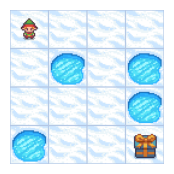

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program


--> The result of taking action 1 is:
     S = 4
     R = 0
     p = 1.0


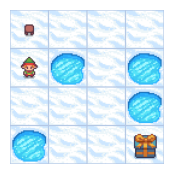

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 1 is:
     S = 8
     R = 0
     p = 1.0


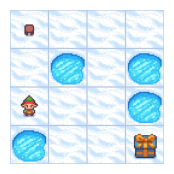

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 2 is:
     S = 9
     R = 0
     p = 1.0


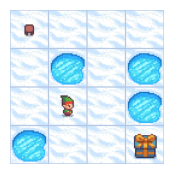

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 2 is:
     S = 10
     R = 0
     p = 1.0


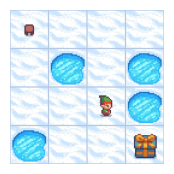

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 1 is:
     S = 14
     R = 0
     p = 1.0


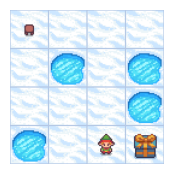

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 2 is:
     S = 15
     R = 1000
     p = 1.0
Episode has terminated!
Final state of environment:


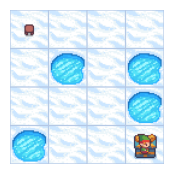

Yay! You reached the goal!


In [32]:
execute_environment(env, suppress_text=False)

# Practical

## Part 1: 

Code up an AI that will employ random action selection in order to drive the agent. Test this random action selection agent with the above environment (i.e., code up a loop as I did above, but instead of taking input from a human user, take it from the AI you coded).

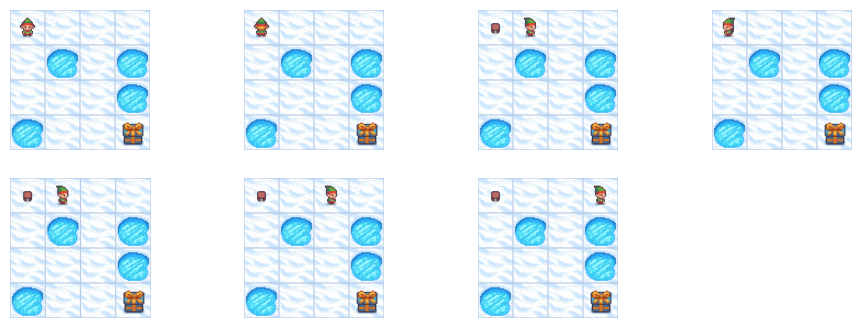

Episode has terminated!
Final state of environment:


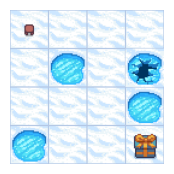

You did not reach the goal.


In [33]:
class AbstractAgent(ABC):
    """ An abstract class to be used as a bass class for agents """
    def get_env_info(self, env):
        self.S_plus, self.A, self.n, self.k = get_spaces_from_env(env)

    @abstractmethod
    def select_action(self, state):
        pass

class RandomSelectionAgent(AbstractAgent):
    """ Agent that randomly selects an action """
    def select_action(self, state):
        """ PRECONDITION: <params> should include key 'action' """
        return np.random.choice(self.A)

execute_environment(env, agent=RandomSelectionAgent())

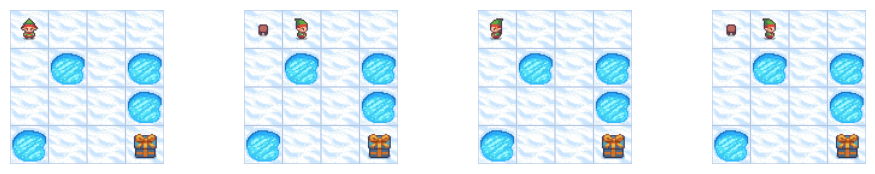

Episode has terminated!
Final state of environment:


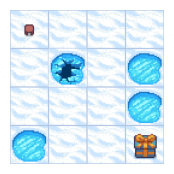

You did not reach the goal.


In [34]:
class RandomPolicyAgent(AbstractAgent):
    """ Agent that uses a policy function to randomly select an action """
    def get_env_info(self, env):
        super().get_env_info(env)
        self.policy = [[1/self.k]*self.k]*self.n

    def select_action(self, state):
        weights = self.policy[state]
        return np.random.choice(self.A, p=weights)

execute_environment(env, agent=RandomPolicyAgent())

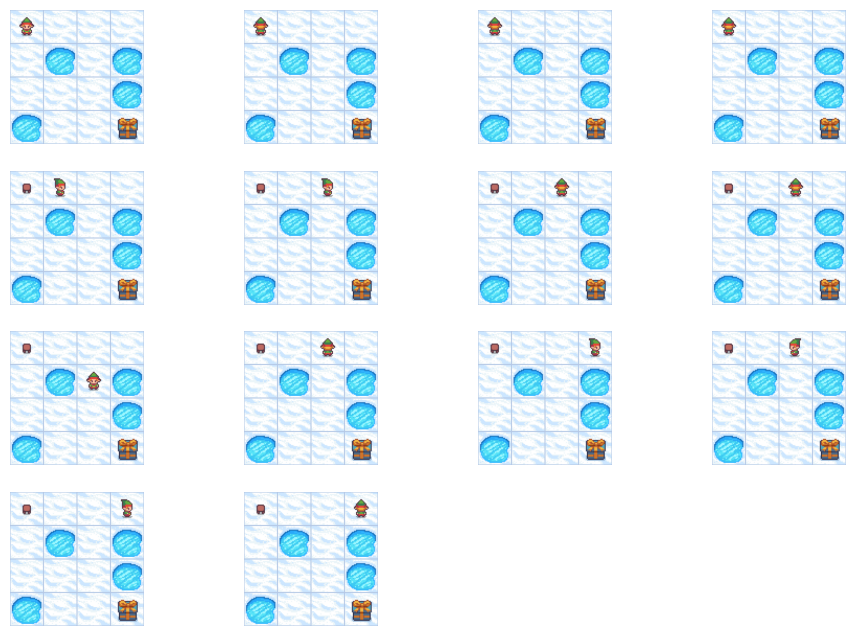

Episode has terminated!
Final state of environment:


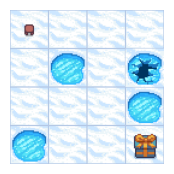

You did not reach the goal.


In [35]:
class RandomPolicyAgent(AbstractAgent):
    """ Agent that uses a policy function to randomly select an action """
    def get_env_info(self, env):
        super().get_env_info(env)
        self.policy = [[1/self.k]*self.k]*self.n

    def select_action(self, state):
        weights = self.policy[state]
        return np.random.choice(self.A, p=weights)

execute_environment(env, agent=RandomPolicyAgent())

## Part 3:


In [36]:
class GPIAgent(AbstractAgent):
    """ Base class for an agent that uses a policy function to select an action """
    def __init__(self, gamma, theta):
        self.gamma = gamma
        self.theta = theta
        self.no_policy_set = True
    
    def _expected_return(self, action_vector):
        """ Helper function (summation over s' and r given <action_vector>) """
        s_prime, reward = action_vector[1:3]
        return reward + self.gamma*self.V[s_prime]

    def _action_argmax(self, s):
        """ Helper to return action that maximizes expected return for given <s> """
        state_obj = self.p[s]
        action = max(state_obj, key=lambda a: self._expected_return(state_obj[a][0]))
        return action

    def get_env_info(self, env):
        super().get_env_info(env)
        self.p = env.unwrapped.P
        self.V = []
        self.terminals = set()
        for s in range(self.n):
            for action_key in self.p[s]:
                vec = self.p[s][action_key][0]
                if vec[-1]:
                    self.V.append(0)
                    self.terminals.add(vec[1])
                else:
                    self.V.append(1)
        if self.no_policy_set:
            self._intialize_policy()

    def policy_evaluation(self, print_num_iter=False):
        """ Evaluate policy using dyn prog policy evaluation algo """
        if self.theta <= 0:
            raise ValueError("Theta must be positive number!")
        num_iter = 0
        while True:
            delta = 0
            num_iter += 1
            for s in range(self.n):
                if s in self.terminals:
                    continue
                old_val = self.V[s]
                self.V[s] = self._value_update(s)
                delta = max(delta, abs(old_val - self.V[s]))
            if delta < self.theta:
                break
        if print_num_iter:
            print(f"theta={self.theta} and gamma={self.gamma} ====> number of steps in evalution: {num_iter}")
        return self.policy, self.V

    @abstractmethod
    def _intialize_policy(self):
        pass

    @abstractmethod
    def _value_update(self, s):
        pass

    @abstractmethod
    def select_action(self, state):
        pass

In [37]:
class StochasticPolicyGPI(GPIAgent):
    """ Agent that uses a stochastic policy function """
    def __init__(self, gamma=0.9, theta=0.02):
        super().__init__(gamma, theta)
    
    def _intialize_policy(self):
        self.policy = np.full((self.n, self.k), 1/self.k)
        self.no_policy_set = False

    def _value_update(self, s):
        sum = 0
        action_vecs = self.p[s]
        for action_key in action_vecs:
            vec = action_vecs[action_key][0]
            sum += self.policy[s][action_key]*self._expected_return(vec)
        return sum

    def select_action(self, state):
        weights = self.policy[state]
        return np.random.choice(self.A, p=weights)

In [38]:
env.reset()
stochastic_gpi_agent = StochasticPolicyGPI(gamma=0.9, theta=0.02)
stochastic_gpi_agent.get_env_info(env)
policy, values = stochastic_gpi_agent.policy_evaluation(print_num_iter=True)
env.close()
print(f"\n\nFinal policy (unchanged because this is prediction, not policy improvement):\n{policy}\n\nFinal values:\n{values}")

theta=0.02 and gamma=0.9 ====> number of steps in evalution: 19


Final policy (unchanged because this is prediction, not policy improvement):
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]

Final values:
[np.float64(1.766129725980429), np.float64(0.9884768263807916), np.float64(7.2101028754900085), np.float64(1.0822430643601517), np.float64(3.38232744547069), 0, np.float64(22.77694898017344), 1, np.float64(15.45146742246838), np.float64(54.40025355508355), np.float64(104.13295170995085), 1, 1, np.float64(127.7521357412518), np.float64(390.1922258160387), 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

## Part 4:

Policy Improvement:


In [39]:
class DeterministicPolicyIteration(GPIAgent):
    """ Agent that uses a deterministic policy table (randomly intiialized) along with policy iteration """
    def __init__(self, gamma=0.9, theta=0.02):
        super().__init__(gamma, theta)
    
    def _intialize_policy(self):
        """ Initialize the policy arbitrarily """
        self.policy = [np.random.choice(self.A) for s in range(self.n)]
        self.no_policy_set = False
    
    def _value_update(self, s):
        action = self.policy[s]
        return self._expected_return(self.p[s][action][0])

    def select_action(self, state):
        return self.policy[state]

    def policy_iteration(self, print_num_iter=False):
        """ Policy iteration as presetned in Ch 4 """
        policy_stable, counter = False, 0
        while not policy_stable:
            policy_stable = True
            counter += 1
            self.policy_evaluation(print_num_iter=print_num_iter)
            for s in range(self.n):
                if s in self.terminals:
                    continue
                old_policy_action = self.policy[s]
                self.policy[s] = self._action_argmax(s)
                if self.policy[s] != old_policy_action:
                    policy_stable = False
        if print_num_iter:
            print(f"Number of iterations for policy iteration: {counter}")
        return self.V, self.policy

env.reset()
deterministic_gpi_agent = DeterministicPolicyIteration(gamma=0.9, theta=0.02)
deterministic_gpi_agent.get_env_info(env)
deterministic_gpi_agent.policy_iteration(print_num_iter=True)
env.close()

theta=0.02 and gamma=0.9 ====> number of steps in evalution: 17
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 4
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
Number of iterations for policy iteration: 7


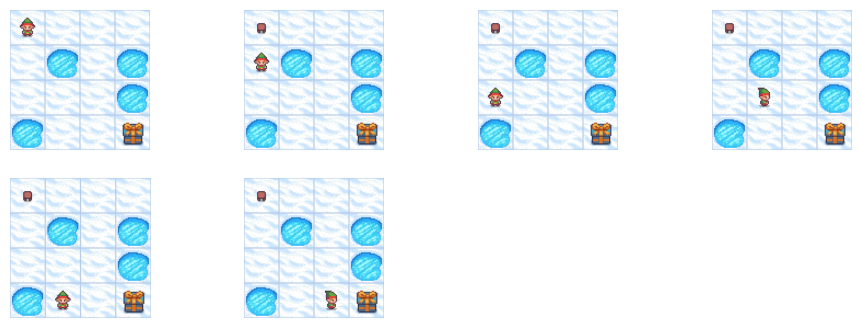

Episode has terminated!
Final state of environment:


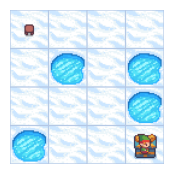

Yay! You reached the goal!


In [40]:
execute_environment(env, agent=deterministic_gpi_agent)

## Part 5:

Code the value iteration process

In [41]:
class ValueIterClass(StochasticPolicyGPI):
    """ Agent that initiailzes a stochastic policy and uses value iteraction to find
    optimal deterministic policy.
    """
    def __init__(self, gamma=0.9, theta=0.02):
        super().__init__(gamma, theta)

    def _value_update(self, s):
        action_vecs = self.p[s]
        return max(map(lambda a: self.policy[s][a]*self._expected_return(action_vecs[a][0]), range(self.k)))

    def select_action(self, state):
        return self.policy[state]

    def value_iteration(self, print_num_iter=False):
        """ Value iteration as presented in Ch 4"""
        self.policy_evaluation(print_num_iter)
        self.policy = list(map(lambda s: self._action_argmax(s), range(self.n)))

env.reset()
value_iter_agent = ValueIterClass(gamma=0.9, theta=0.02)
value_iter_agent.get_env_info(env)
value_iter_agent.value_iteration(print_num_iter=True)
env.close()

theta=0.02 and gamma=0.9 ====> number of steps in evalution: 7


Clearly value iteration takes far fewer iterations than policy iteration. Now we will test value iteration:

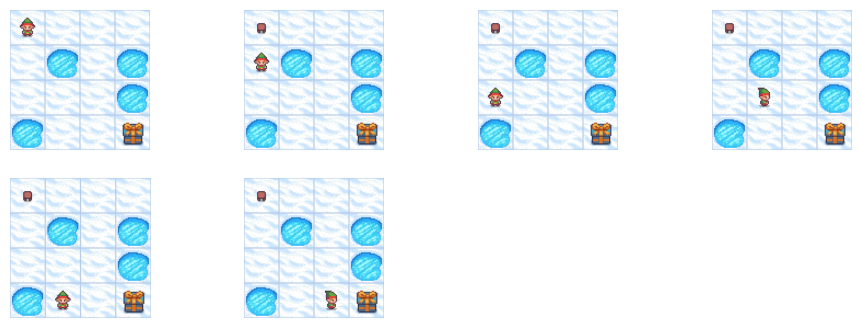

Episode has terminated!
Final state of environment:


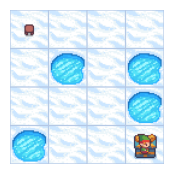

Yay! You reached the goal!


In [42]:
execute_environment(env, agent=value_iter_agent)

<!-- # Appendix A

Here is the full print of "env.unwrapped.P": -->